In [ ]:
#do pobrania danych z UC Irvine
!pip install ucimlrepo

In [ ]:
#Instalacja i import bibliotek

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')

In [ ]:
#Wczytanie danych z UCI Repository
online_shoppers = fetch_ucirepo(id=468)

X_raw = online_shoppers.data.features
y_raw = online_shoppers.data.targets

# Połączenie cech i zmiennej docelowej w jeden DataFrame
df = pd.concat([X_raw, y_raw], axis=1)

print('Pierwsze 5 wierszy danych:')
display(df.head())

print('\nRozmiar zbioru danych:')
print(df.shape)

print('\nNazwy kolumn:')
print(df.columns.tolist())

print('\nInformacje o zbiorze danych:')
print(online_shoppers.metadata)

print('\nInformacje o zmiennych:')
display(online_shoppers.variables)

Pierwsze 5 wierszy danych:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



Rozmiar zbioru danych:
(12330, 18)

Nazwy kolumn:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Informacje o zbiorze danych:
{'uci_id': 468, 'name': 'Online Shoppers Purchasing Intention Dataset', 'repository_url': 'https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/468/data.csv', 'abstract': 'Of the 12,330 sessions in the dataset,\n84.5% (10,422) were negative class samples that did not\nend with shopping, and the rest (1908) were positive class\nsamples ending with shopping.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 12330, 'num_features': 17, 'feature_types': ['Integer', 'Rea

,name,role,type,demographic,description,units,missing_values
0,Administrative,Feature,Integer,None,None,None,no
1,Administrative_Duration,Feature,Integer,None,None,None,no
2,Informational,Feature,Integer,None,None,None,no
3,Informational_Duration,Feature,Integer,None,None,None,no
4,ProductRelated,Feature,Integer,None,None,None,no
5,ProductRelated_Duration,Feature,Continuous,None,None,None,no
6,BounceRates,Feature,Continuous,None,None,None,no
7,ExitRates,Feature,Continuous,None,None,None,no
8,PageValues,Feature,Integer,None,None,None,no
9,SpecialDay,Feature,Integer,None,None,None,no


In [ ]:
#Podstawowa eksploracja danych

print('\nInformacje o typach danych:')
df.info()

print('\nStatystyki opisowe:')
display(df.describe(include='all'))

print('\nBraki danych w kolumnach:')
display(df.isnull().sum())

print('\nLiczba duplikatów:')
print(df.duplicated().sum())



Informacje o typach danych:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64 

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330,12330
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,3,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May,NaN,NaN,NaN,NaN,Returning_Visitor,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3364,NaN,NaN,NaN,NaN,10551,9462,10422
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,NaN,2.124006,2.357097,3.147364,4.069586,NaN,NaN,NaN
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,NaN,0.911325,1.717277,2.401591,4.025169,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,NaN,2.000000,2.000000,1.000000,2.000000,NaN,NaN,NaN
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,NaN,2.000000,2.000000,3.000000,2.000000,NaN,NaN,NaN
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,NaN,3.000000,2.000000,4.000000,4.000000,NaN,NaN,NaN



Braki danych w kolumnach:


,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0



Liczba duplikatów:
125


In [ ]:
#Usunięcie duplikatów
df = df.drop_duplicates()

print('\nLiczba duplikatów:')
print(df.duplicated().sum())


Kolumny w danych:
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

Rozkład zmiennej Revenue:


,count
Revenue,
False,10297
True,1908



Procentowy rozkład zmiennej Revenue:


,proportion
Revenue,
False,84.367063
True,15.632937


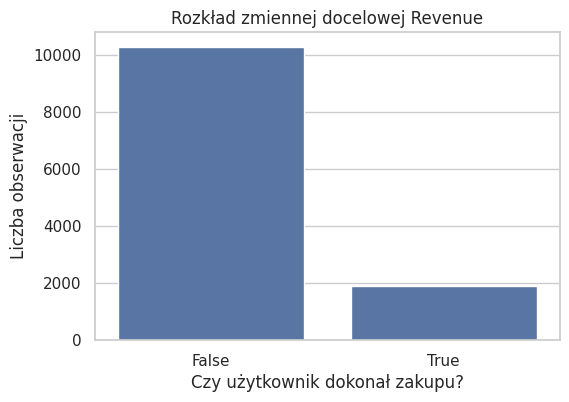

In [ ]:
#Sprawdzenie i przygotowanie zmiennej docelowej Revenue

print('\nRozkład zmiennej Revenue:')
display(df['Revenue'].value_counts())

print('\nProcentowy rozkład zmiennej Revenue:')
display(df['Revenue'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='Revenue', data=df)
plt.title('Rozkład zmiennej docelowej Revenue')
plt.xlabel('Czy użytkownik dokonał zakupu?')
plt.ylabel('Liczba obserwacji')
plt.show()


In [ ]:
#Podział zmiennych na numeryczne i kategoryczne

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

if 'Revenue' in num_cols:
    num_cols.remove('Revenue')

if 'Revenue' in cat_cols:
    cat_cols.remove('Revenue')

print('Zmienne numeryczne:')
print(num_cols)

print('\nZmienne kategoryczne:')
print(cat_cols)

Zmienne numeryczne:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Zmienne kategoryczne:
['Month', 'VisitorType', 'Weekend']


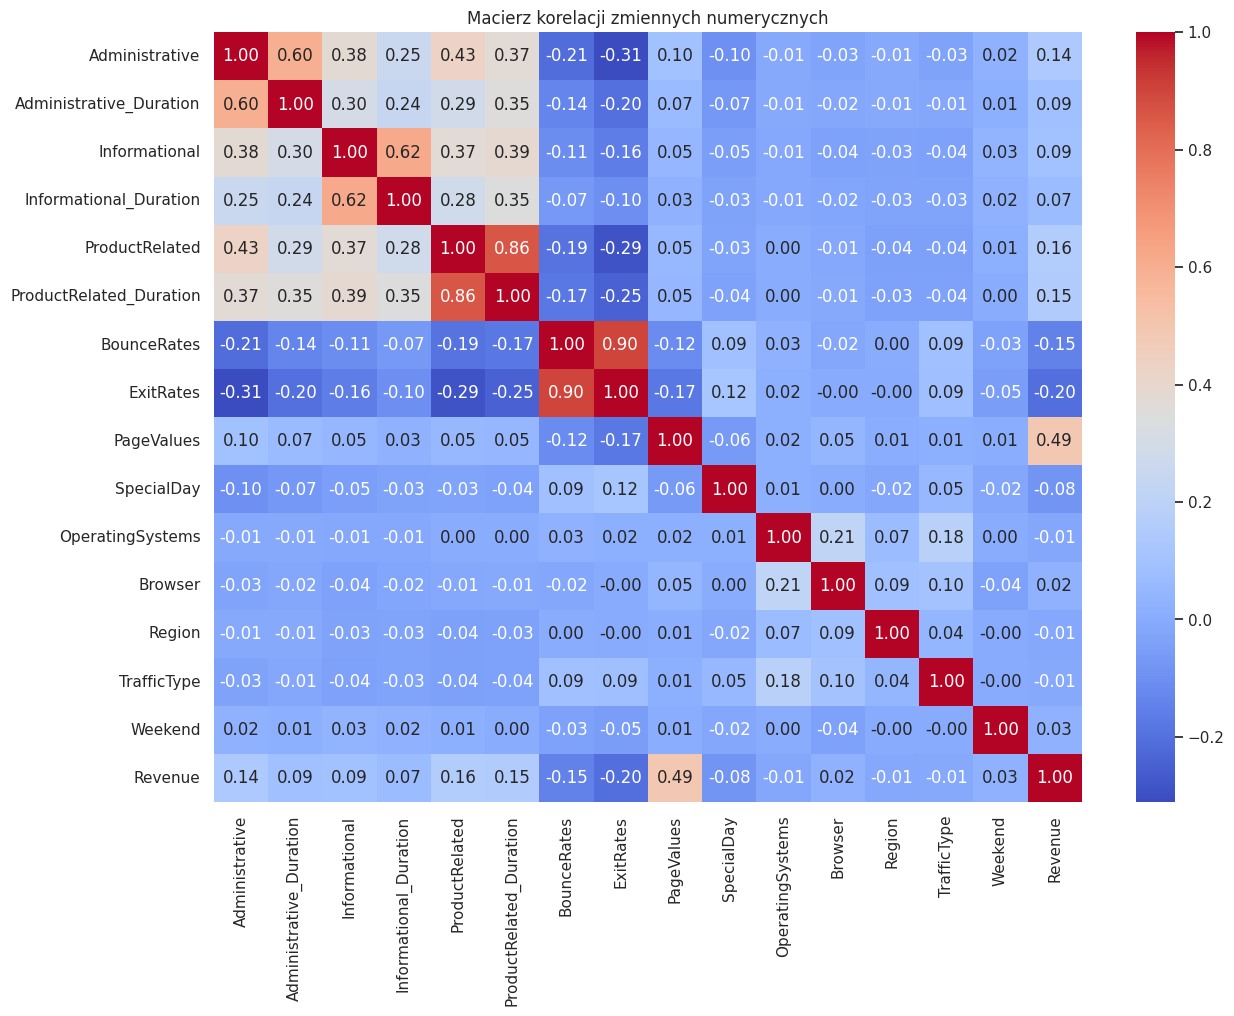

Korelacja zmiennych numerycznych ze zmienną Revenue:


,Revenue
Revenue,1.000000
PageValues,0.491894
ProductRelated,0.156042
ProductRelated_Duration,0.150077
Administrative,0.136330
Informational,0.093626
Administrative_Duration,0.091768
Informational_Duration,0.069358
Weekend,0.027729
Browser,0.024052


In [ ]:

#Analiza korelacji i wybór najważniejszych zmiennych


corr_df = df.copy()

#Zamiana Revenue na 0/1 do obliczenia korelacji
if corr_df['Revenue'].dtype == 'bool':
    corr_df['Revenue'] = corr_df['Revenue'].astype(int)
else:
    corr_df['Revenue'] = corr_df['Revenue'].map({True: 1, False: 0}).fillna(corr_df['Revenue'])

#Heatmapa korelacji
plt.figure(figsize=(14, 10))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Macierz korelacji zmiennych numerycznych')
plt.show()

#Korelacja ze zmienną Revenue
print('Korelacja zmiennych numerycznych ze zmienną Revenue:')
corr_with_target = corr_df.corr(numeric_only=True)['Revenue'].sort_values(ascending=False)
display(corr_with_target)


In [ ]:
#Wybór najważniejszych zmiennych do wizualizacji

#Wybór na podstawie korelacji ze zmienną Revenue,znaczenia biznesowego, interpretowalności

#Wybrane zmienne numeryczne
selected_num_cols = [
    'PageValues',
    'BounceRates',
    'ExitRates',
    'ProductRelated_Duration'
]

#Wybrane zmienne kategoryczne
selected_cat_cols = [
    'Month',
    'VisitorType',
    'Weekend'
]

print('Wybrane zmienne numeryczne:')
print(selected_num_cols)

print('Wybrane zmienne kategoryczne:')
print(selected_cat_cols)

Wybrane zmienne numeryczne:
['PageValues', 'BounceRates', 'ExitRates', 'ProductRelated_Duration']
Wybrane zmienne kategoryczne:
['Month', 'VisitorType', 'Weekend']


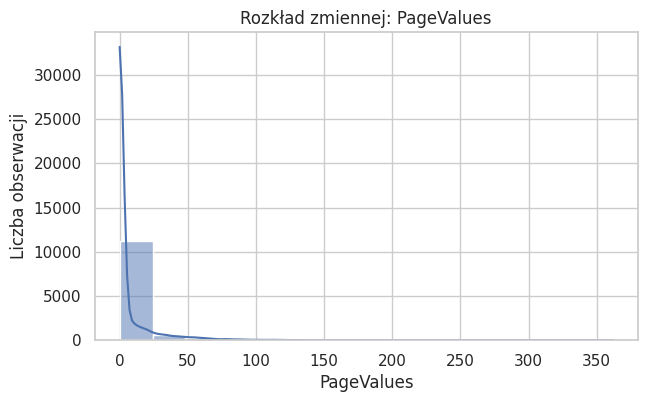

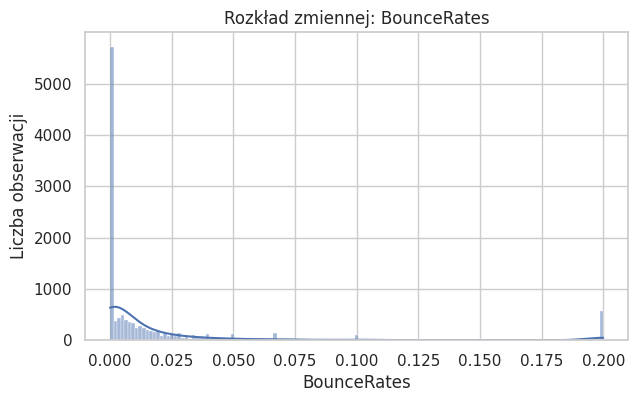

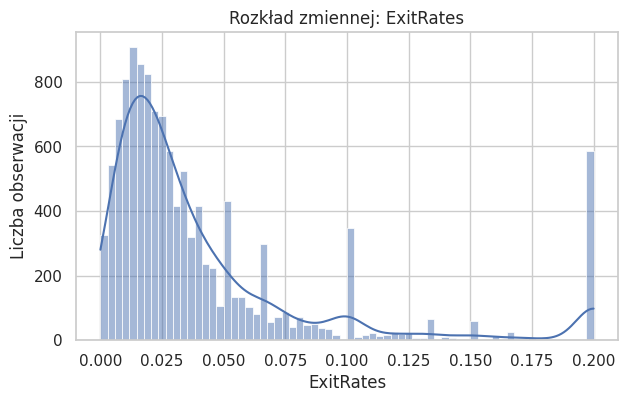

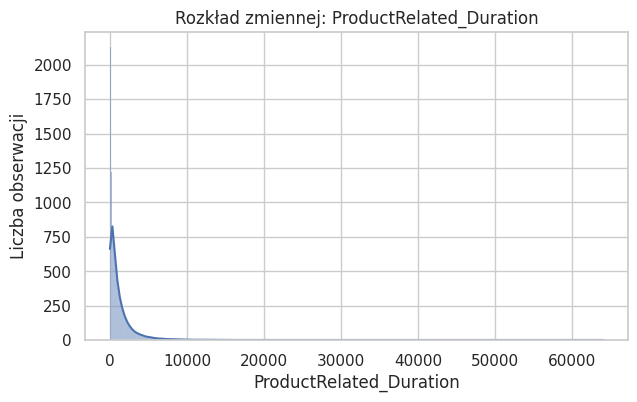

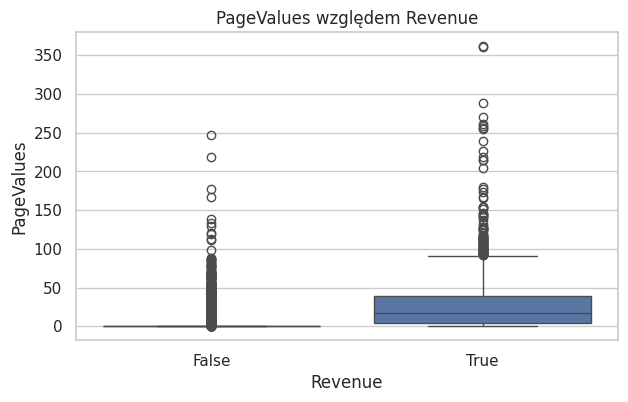

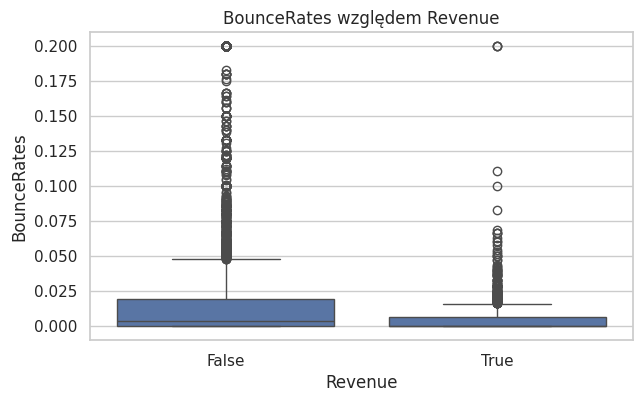

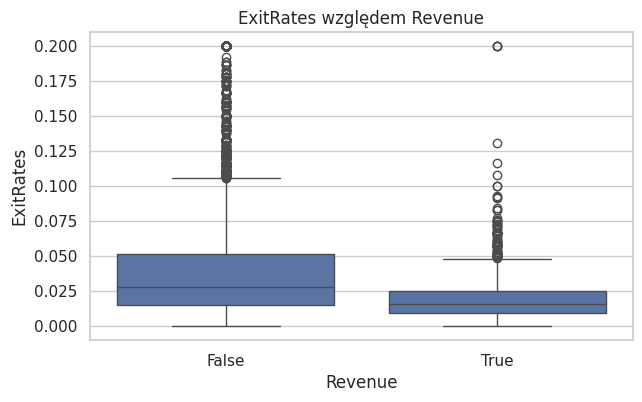

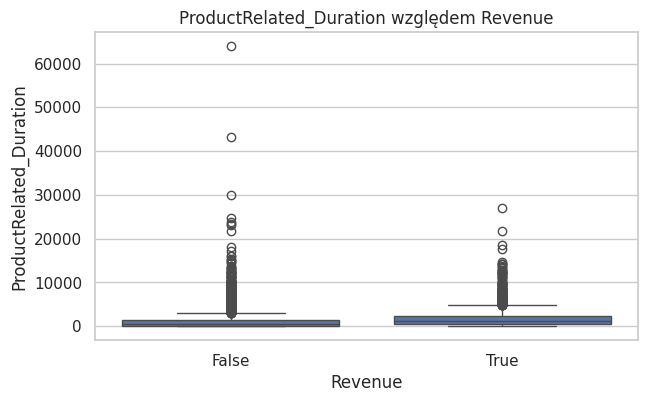

In [ ]:
#Analiza wybranych zmiennych numerycznych

# Histogramy
for col in selected_num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Rozkład zmiennej: {col}')
    plt.xlabel(col)
    plt.ylabel('Liczba obserwacji')
    plt.show()

# Boxploty względem Revenue
for col in selected_num_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x='Revenue', y=col, data=df)
    plt.title(f'{col} względem Revenue')
    plt.xlabel('Revenue')
    plt.ylabel(col)
    plt.show()

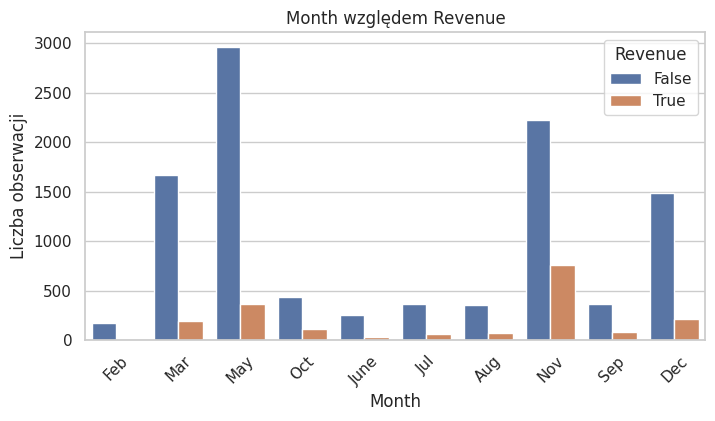

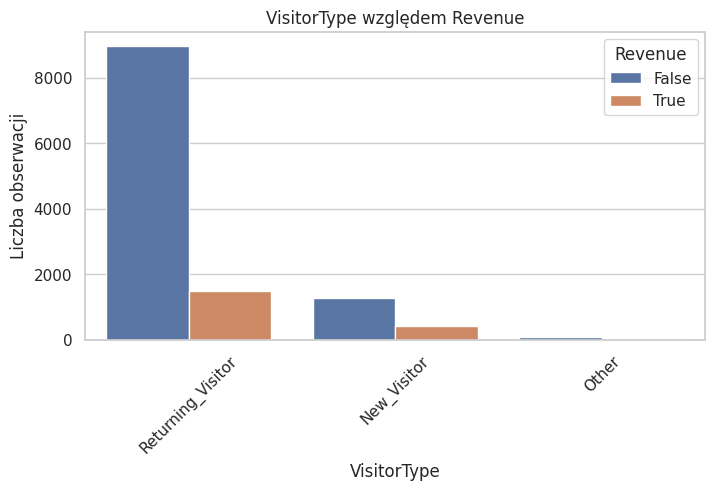

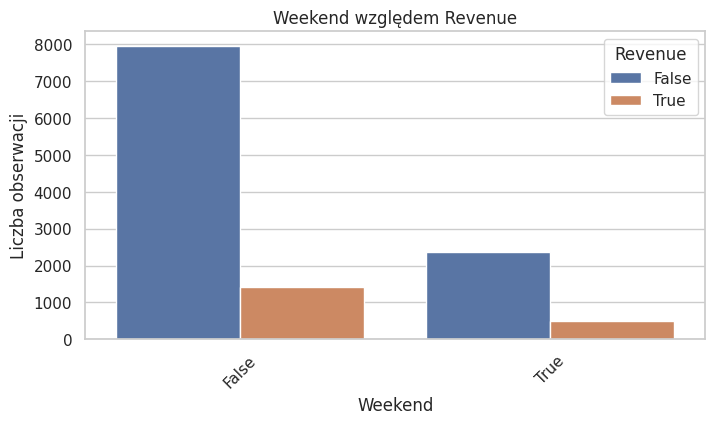

In [ ]:
#Analiza wybranych zmiennych kategorycznych

for col in selected_cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, hue='Revenue', data=df)
    plt.title(f'{col} względem Revenue')
    plt.xlabel(col)
    plt.ylabel('Liczba obserwacji')
    plt.xticks(rotation=45)
    plt.legend(title='Revenue')
    plt.show()



In [ ]:
#Przygotowanie danych do modelowania

#Kodowanie zmiennych kategorycznych
df_encoded = pd.get_dummies(df, drop_first=True)

# Zamiana Revenue na 0/1
if df_encoded['Revenue'].dtype == 'bool':
    df_encoded['Revenue'] = df_encoded['Revenue'].astype(int)

X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

print('Rozmiar X:', X.shape)
print('Rozmiar y:', y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Rozmiar X: (12205, 26)
Rozmiar y: (12205,)



Model: Regresja logistyczna
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2059
           1       0.77      0.42      0.54       382

    accuracy                           0.89      2441
   macro avg       0.84      0.70      0.74      2441
weighted avg       0.88      0.89      0.88      2441



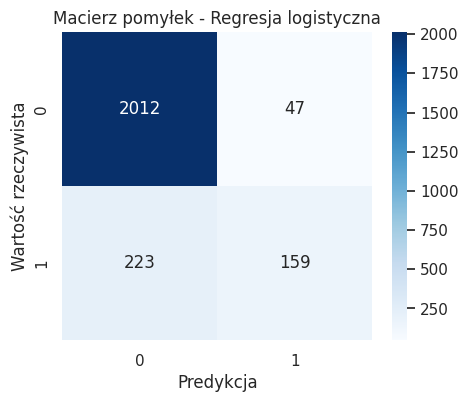


Model: Drzewo decyzyjne
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2059
           1       0.55      0.55      0.55       382

    accuracy                           0.86      2441
   macro avg       0.73      0.74      0.74      2441
weighted avg       0.86      0.86      0.86      2441



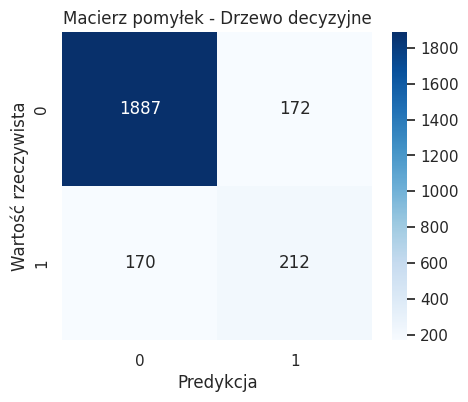


Model: Las losowy
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      2059
           1       0.77      0.59      0.67       382

    accuracy                           0.91      2441
   macro avg       0.85      0.78      0.81      2441
weighted avg       0.90      0.91      0.90      2441



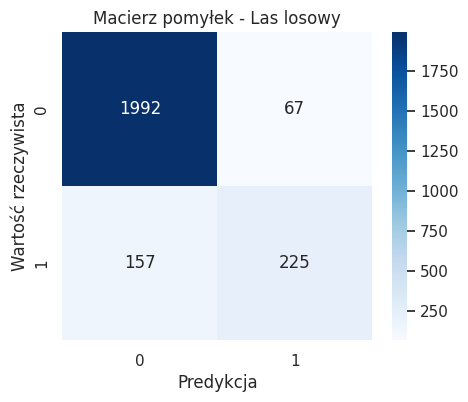


Model: KNN
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      2059
           1       0.67      0.38      0.48       382

    accuracy                           0.87      2441
   macro avg       0.78      0.67      0.71      2441
weighted avg       0.86      0.87      0.86      2441



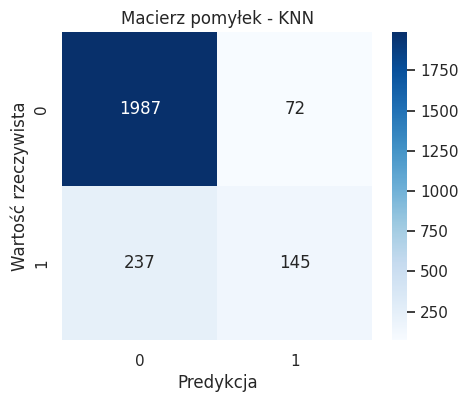

In [ ]:
#Budowa modeli klasyfikacyjnych

models = {
    'Regresja logistyczna': LogisticRegression(max_iter=1000, random_state=42),
    'Drzewo decyzyjne': DecisionTreeClassifier(random_state=42),
    'Las losowy': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

results = []
trained_models = {}

for name, model in models.items():
    print('\n' + '=' * 70)
    print(f'Model: {name}')
    print('=' * 70)

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)


    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })

    trained_models[name] = model

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Macierz pomyłek - {name}')
    plt.xlabel('Predykcja')
    plt.ylabel('Wartość rzeczywista')
    plt.show()


Porównanie modeli:


,Model,Accuracy,Precision,Recall,F1-score
2,Las losowy,0.908234,0.770548,0.589005,0.667656
1,Drzewo decyzyjne,0.859893,0.552083,0.554974,0.553525
0,Regresja logistyczna,0.889390,0.771845,0.416230,0.540816
3,KNN,0.873413,0.668203,0.379581,0.484140


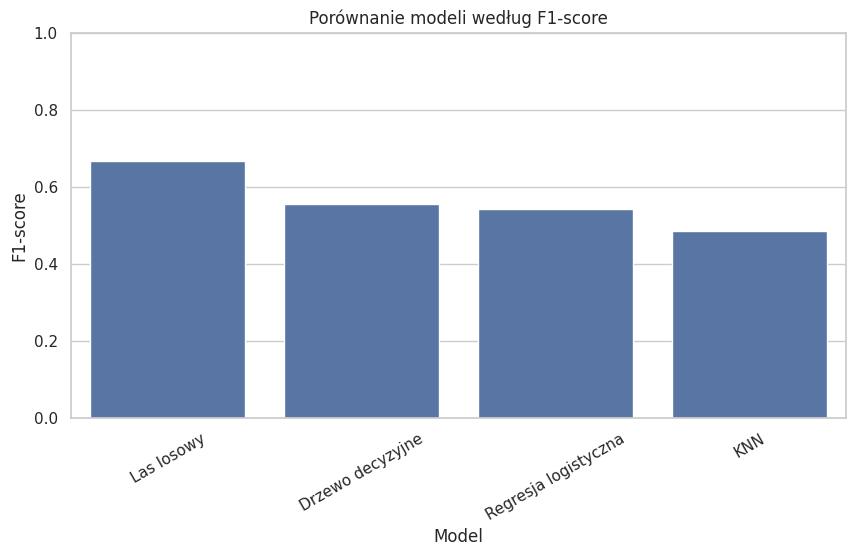

In [ ]:
#Porównanie modeli

results_df = pd.DataFrame(results).sort_values(by='F1-score', ascending=False)

print('Porównanie modeli:')
display(results_df)

plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='F1-score', data=results_df)
plt.title('Porównanie modeli według F1-score')
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

Wyniki walidacji krzyżowej:


,Model,CV Accuracy,CV Precision,CV Recall,CV F1-score
2,Las losowy,0.902704,0.752959,0.562246,0.643545
1,Drzewo decyzyjne,0.857948,0.545339,0.553732,0.549299
0,Regresja logistyczna,0.882016,0.744800,0.372868,0.496579
3,KNN,0.870545,0.658759,0.356458,0.462208


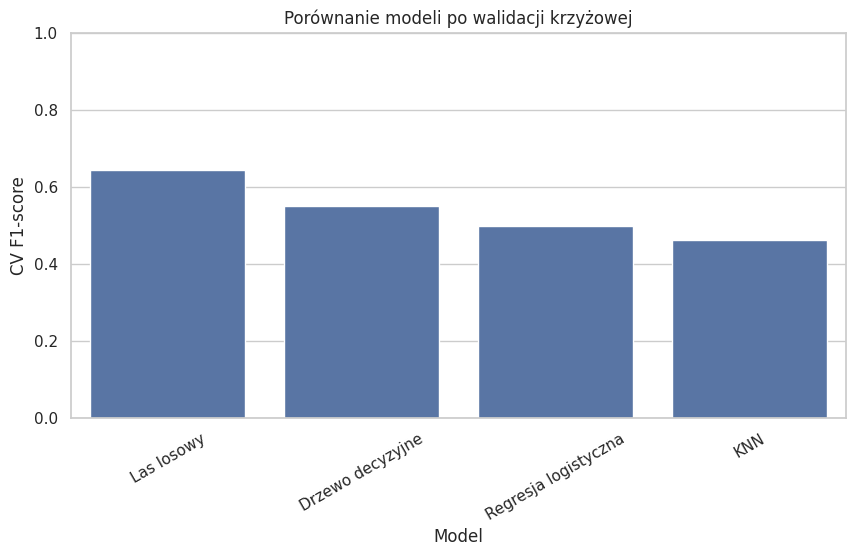

In [ ]:
#Walidacja krzyżowa

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1'
    }

    scores = cross_validate(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring=scoring
    )

    cv_results.append({
        'Model': name,
        'CV Accuracy': np.mean(scores['test_accuracy']),
        'CV Precision': np.mean(scores['test_precision']),
        'CV Recall': np.mean(scores['test_recall']),
        'CV F1-score': np.mean(scores['test_f1'])
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by='CV F1-score', ascending=False)

print('Wyniki walidacji krzyżowej:')
display(cv_results_df)

plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='CV F1-score', data=cv_results_df)
plt.title('Porównanie modeli po walidacji krzyżowej')
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()


Najlepszy model według CV F1-score: Las losowy
Wyniki accuracy w kolejnych foldach:
[0.90373784 0.89912954 0.90220174 0.90373784 0.90471311]
Średnia accuracy: 0.9027
95% przedział ufności: [0.9010, 0.9041]


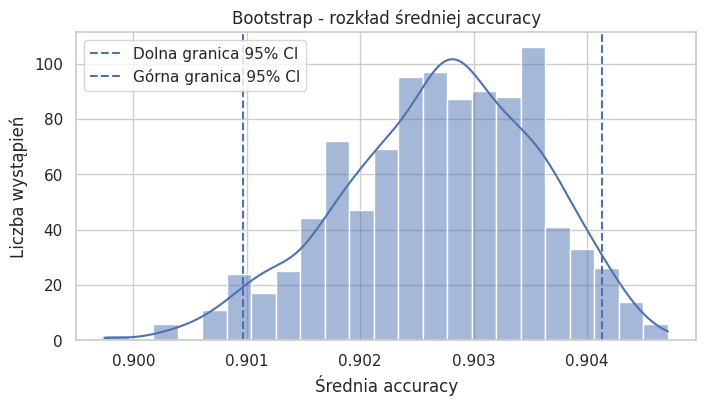

In [ ]:
#Bootstrap dla najlepszego modelu

best_model_name = cv_results_df.iloc[0]['Model']
best_model = models[best_model_name]

print('Najlepszy model według CV F1-score:', best_model_name)

scores = cross_val_score(
    best_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print('Wyniki accuracy w kolejnych foldach:')
print(scores)

n_bootstraps = 1000
boot_means = []

for i in range(n_bootstraps):
    boot_sample = np.random.choice(scores, size=len(scores), replace=True)
    boot_means.append(np.mean(boot_sample))

boot_means = np.array(boot_means)
ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)

print(f'Średnia accuracy: {np.mean(scores):.4f}')
print(f'95% przedział ufności: [{ci_lower:.4f}, {ci_upper:.4f}]')

plt.figure(figsize=(8, 4))
sns.histplot(boot_means, kde=True)
plt.axvline(ci_lower, linestyle='--', label='Dolna granica 95% CI')
plt.axvline(ci_upper, linestyle='--', label='Górna granica 95% CI')
plt.title('Bootstrap - rozkład średniej accuracy')
plt.xlabel('Średnia accuracy')
plt.ylabel('Liczba wystąpień')
plt.legend()
plt.show()

Najlepsze parametry Random Forest:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Najlepszy wynik F1 w GridSearchCV:
0.6513076911782654
Wyniki dostrojonego Random Forest na zbiorze testowym:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2059
           1       0.74      0.58      0.65       382

    accuracy                           0.90      2441
   macro avg       0.83      0.77      0.80      2441
weighted avg       0.90      0.90      0.90      2441



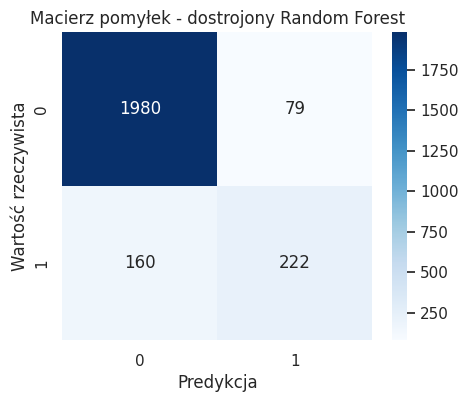

In [ ]:
#Strojenie hiperparametrów - GridSearchCV dla Random Forest

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print('Najlepsze parametry Random Forest:')
print(grid.best_params_)

print('Najlepszy wynik F1 w GridSearchCV:')
print(grid.best_score_)

best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)

print('Wyniki dostrojonego Random Forest na zbiorze testowym:')
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Macierz pomyłek - dostrojony Random Forest')
plt.xlabel('Predykcja')
plt.ylabel('Wartość rzeczywista')
plt.show()

# Nowa sekcja

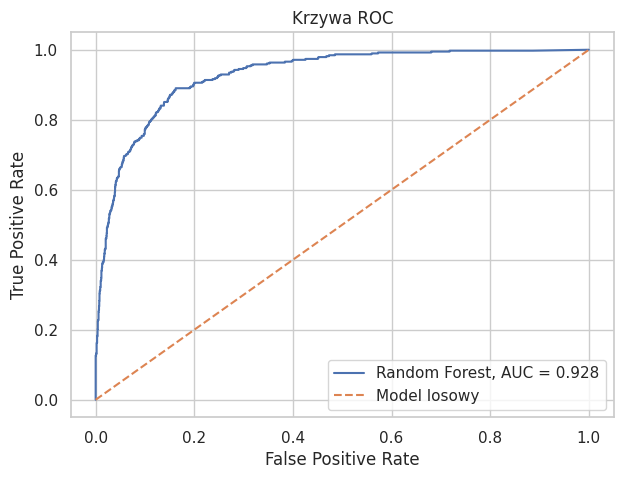

AUC: 0.9283


In [ ]:
#Krzywa ROC i AUC

y_proba = best_rf.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Random Forest, AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Model losowy')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC')
plt.legend()
plt.show()

print(f'AUC: {auc:.4f}')

Najważniejsze cechy według Random Forest:


,0
PageValues,0.402388
ProductRelated_Duration,0.086884
ExitRates,0.084879
ProductRelated,0.068550
Administrative_Duration,0.054967
BounceRates,0.054827
Administrative,0.040561
TrafficType,0.027381
Region,0.025471
Informational_Duration,0.025259


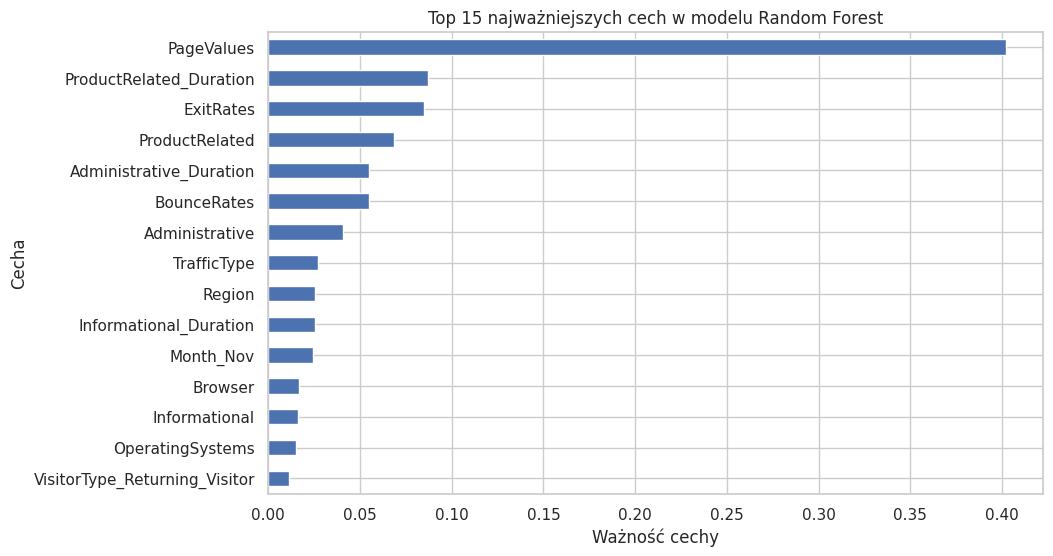

In [ ]:
#Ważność cech - Random Forest

feature_importance = pd.Series(best_rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print('Najważniejsze cechy według Random Forest:')
display(feature_importance.head(15))

plt.figure(figsize=(10, 6))
feature_importance.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 najważniejszych cech w modelu Random Forest')
plt.xlabel('Ważność cechy')
plt.ylabel('Cecha')
plt.show()
